# Week 05 - Static Web Scraping Books

| 항목 | 내용 |
|---|---|
| 이름 | 이성민 |
| 학과 | 소프트웨어융합과 |
| 학년 | 2학년 |
| 학번 | 2151050 |
| 시트 기준 열 | 0403_Self HomeWork scrapping books |

이 노트북은 과제 요구사항을 학습용으로 재구성한 설명형 산출물이다. 원본 코드를 그대로 복사하지 않고, 같은 개념을 작은 로컬 예제로 다시 구현한다.

## 목표

정적 HTML에서 책 정보를 파싱하고 데이터프레임으로 정리한다.

모든 코드는 외부 서비스 접속 없이 실행되도록 구성했다. 실제 API나 웹사이트를 사용할 때는 같은 처리 흐름에서 데이터 입력 부분만 교체하면 된다.

## 1. 정적 HTML 파싱

정적 페이지는 HTML 문서 안에 데이터가 이미 들어 있다. `html.parser`를 사용하면 추가 패키지 없이도 태그와 속성을 읽어 책 정보를 추출할 수 있다.

In [1]:
from html.parser import HTMLParser
import pandas as pd
import matplotlib.pyplot as plt

html = '''
<section class="catalog">
  <article class="book" data-rating="Three">
    <h3>Python Basics</h3><p class="price">£31.20</p><p class="stock">In stock</p>
  </article>
  <article class="book" data-rating="Five">
    <h3>Data Analysis Lab</h3><p class="price">£45.50</p><p class="stock">In stock</p>
  </article>
  <article class="book" data-rating="Two">
    <h3>Web Scraping Notes</h3><p class="price">£22.90</p><p class="stock">Out of stock</p>
  </article>
</section>
'''

class BookParser(HTMLParser):
    def __init__(self):
        super().__init__()
        self.books = []
        self.current = None
        self.current_field = None

    def handle_starttag(self, tag, attrs):
        attrs = dict(attrs)
        if tag == "article" and attrs.get("class") == "book":
            self.current = {"rating": attrs.get("data-rating")}
        elif self.current is not None and tag == "h3":
            self.current_field = "title"
        elif self.current is not None and tag == "p":
            self.current_field = attrs.get("class")

    def handle_data(self, data):
        text = data.strip()
        if self.current is not None and self.current_field and text:
            self.current[self.current_field] = text

    def handle_endtag(self, tag):
        if tag == "article" and self.current is not None:
            self.books.append(self.current)
            self.current = None
        self.current_field = None

parser = BookParser()
parser.feed(html)
books = pd.DataFrame(parser.books)
books

,rating,title,price,stock
0,Three,Python Basics,£31.20,In stock
1,Five,Data Analysis Lab,£45.50,In stock
2,Two,Web Scraping Notes,£22.90,Out of stock


## 2. 데이터 정제

크롤링한 값은 대부분 문자열이다. 가격 계산을 하려면 통화 기호를 제거하고 숫자형으로 바꿔야 한다.

In [2]:
rating_score = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

books["price_gbp"] = books["price"].str.replace("£", "", regex=False).astype(float)
books["rating_score"] = books["rating"].map(rating_score)
books["available"] = books["stock"].eq("In stock")

assert books["price_gbp"].gt(0).all()
assert books["rating_score"].between(1, 5).all()
books

,rating,title,price,stock,price_gbp,rating_score,available
0,Three,Python Basics,£31.20,In stock,31.2,3,True
1,Five,Data Analysis Lab,£45.50,In stock,45.5,5,True
2,Two,Web Scraping Notes,£22.90,Out of stock,22.9,2,False


## 3. 분석과 시각화

파싱한 데이터를 DataFrame으로 정리하면 평균 가격, 재고 상태, 평점 분포 같은 분석을 바로 수행할 수 있다.

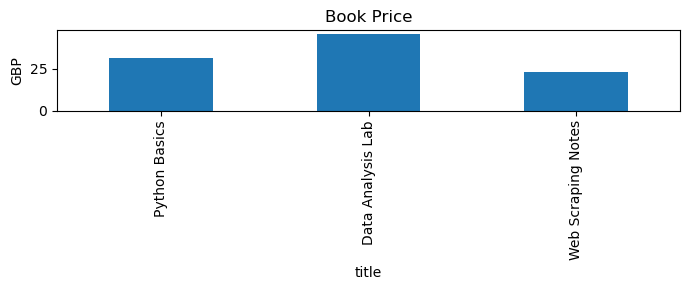

,price_gbp,rating_score,available
avg_price,33.2,NaN,NaN
max_rating,NaN,5.0,NaN
in_stock,NaN,NaN,2.0


In [3]:
summary = books.agg(
    avg_price=("price_gbp", "mean"),
    max_rating=("rating_score", "max"),
    in_stock=("available", "sum"),
)

ax = books.plot(kind="bar", x="title", y="price_gbp", figsize=(7, 3), legend=False, title="Book Price")
ax.set_ylabel("GBP")
plt.tight_layout()
plt.show()

display(summary)